In [ ]:
!pip -q install amplpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 16.3 MB/s eta 0:00:00


In [ ]:
# 1. Instalación e inicialización de AMPL con tu licencia Community Edition
from amplpy import ampl_notebook

# Inicializa AMPL en Colab con tu UUID (Community Edition) Inicializar AMPL
ampl = ampl_notebook(
    modules=["highs", "cbc", "gurobi", "cplex", "coin"],  # solvers disponibles
    license_uuid="936b618d-a013-406f-9809-49679f557c26"
)

Licensed to AMPL Academic Community Edition License for <m.godoyseplveda@uandresbello.edu>.


In [ ]:
%%writefile 11_7_2.mod
param c1;         # coef. x1 en la FO
param c2;         # coef. x2

param a11;        # coef. x1 en restr. principal
param a12;        # coef. x2 "
param rhs;        # lado derecho restr. principal

param ubx1;       # cota superior x1

var x1 integer >= 0 <= ubx1;
var x2 integer >= 0;

maximize Z: c1*x1 + c2*x2;

s.t. R1:  a11*x1 + a12*x2 >= rhs;


Writing 11_7_2.mod


In [ ]:
%%writefile 11_7_2.dat
param c1  := -3;
param c2  :=  5;

param a11 :=  5;
param a12 := -7;
param rhs :=  3;

param ubx1 := 3;


Writing 11_7_2.dat


In [ ]:
ampl.read('11_7_2.mod')
ampl.readData('11_7_2.dat')

ampl.option['solver'] = 'cbc'        # MIP puro
ampl.solve()
ampl.display('x1','x2','Z')


cbc 2.10.12: cbc 2.10.12: optimal solution; objective -1
0 simplex iterations
x1 = 2
x2 = 1
Z = -1



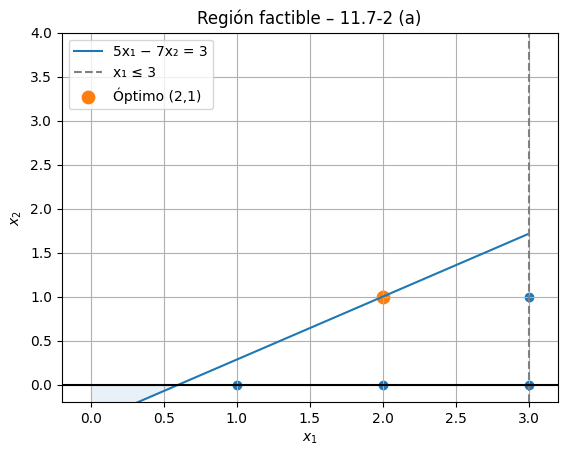

In [ ]:
import numpy as np, matplotlib.pyplot as plt, itertools

x1 = np.linspace(0, 3, 400)
r  = (5*x1 - 3) / 7           # frontera 5x1 − 7x2 = 3

plt.figure()
plt.plot(x1, r, label='5x₁ − 7x₂ = 3')
plt.axvline(3, color='grey', ls='--', label='x₁ ≤ 3')
plt.axhline(0, color='k')
plt.fill_between(x1, r, 0, where=r<=0, alpha=0.1)

# puntos enteros viables
for i, j in itertools.product(range(4), range(5)):
    if 5*i - 7*j >= 3:
        plt.scatter(i, j, c='tab:blue')
plt.scatter(2, 1, s=80, c='tab:orange', label='Óptimo (2,1)')

plt.xlim(-0.2, 3.2); plt.ylim(-0.2, 4)
plt.xlabel('$x_1$'); plt.ylabel('$x_2$'); plt.grid()
plt.legend(); plt.title('Región factible – 11.7-2 (a)')
plt.show()
